In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [2]:
X,y = load_iris(return_X_y=True, as_frame=True)
df_raw = X
df_raw['species'] = y
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [3]:
df_raw.sample(10, random_state=2025)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
2,4.7,3.2,1.3,0.2,0
148,6.2,3.4,5.4,2.3,2
112,6.8,3.0,5.5,2.1,2
132,6.4,2.8,5.6,2.2,2
0,5.1,3.5,1.4,0.2,0
113,5.7,2.5,5.0,2.0,2
34,4.9,3.1,1.5,0.2,0
51,6.4,3.2,4.5,1.5,1
135,7.7,3.0,6.1,2.3,2
5,5.4,3.9,1.7,0.4,0


In [4]:
#Step 2 Preprocessing
#Nombre predictora sin espacios en blanco
#Variable species: 0=setosa, 1=versicolor, 2=virginica
df_baking = df_raw.copy()
df_baking.columns = df_baking.columns.str.replace(' ','_').str.replace('(','').str.replace(')','')
species_new = {0:'setosa',1:'versicolor',2:'virginica'}
df_baking['species'] = df_baking['species'].replace(species_new)
df_baking['species'] = df_baking['species'].astype('category')
df = df_baking.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   sepal_length_cm  150 non-null    float64 
 1   sepal_width_cm   150 non-null    float64 
 2   petal_length_cm  150 non-null    float64 
 3   petal_width_cm   150 non-null    float64 
 4   species          150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


In [95]:
df.sample(10, random_state=2025)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
2,4.7,3.2,1.3,0.2,setosa
148,6.2,3.4,5.4,2.3,virginica
112,6.8,3.0,5.5,2.1,virginica
132,6.4,2.8,5.6,2.2,virginica
0,5.1,3.5,1.4,0.2,setosa
113,5.7,2.5,5.0,2.0,virginica
34,4.9,3.1,1.5,0.2,setosa
51,6.4,3.2,4.5,1.5,versicolor
135,7.7,3.0,6.1,2.3,virginica
5,5.4,3.9,1.7,0.4,setosa


In [5]:
#Step 3: EDA
df_train, df_test = train_test_split(df, test_size=0.1, stratify=df['species'],  random_state=2025)
df_train # Muestra desordenado y es necesrio resetear el orden
df_train = df_train.reset_index(drop=True) #Si le coloco False permanece la columna index y no conviene por eso se coloca drop=True
df_test =  df_test.reset_index(drop=True) # Y ordena
df_train
#X_train = df_train.drop(columns = 'y')
#y_train = df_train['y']
#X_test = df_test.drop(columns = 'y')
#y_test = df_test['y']
df_train.shape, df_test.shape

((135, 5), (15, 5))

In [97]:
#Estadistica descriptiva la idea es entender las medidas de tendencia central y las de dsipersion
display(df_train.describe(include="number").T)
display(df_train.describe(include="category").T)
#El Dataset tiene 150 observaciones, 50 de cada tipo, hay tres tipos
#135 es el dataset de aprendizaje entonces de cada tipo habra 48, entonces hay un desbalance de tipo la idea es que la maquina parta
#pero preservando el rango de species  stratify=df['species'] ahora cada tipo tiene 45

,count,mean,std,min,25%,50%,75%,max
sepal_length_cm,135.0,5.818519,0.813798,4.3,5.10,5.8,6.4,7.9
sepal_width_cm,135.0,3.059259,0.452076,2.0,2.80,3.0,3.4,4.4
petal_length_cm,135.0,3.745185,1.764396,1.0,1.55,4.4,5.1,6.9
petal_width_cm,135.0,1.200741,0.760449,0.1,0.30,1.3,1.8,2.5


,count,unique,top,freq
species,135,3,setosa,45


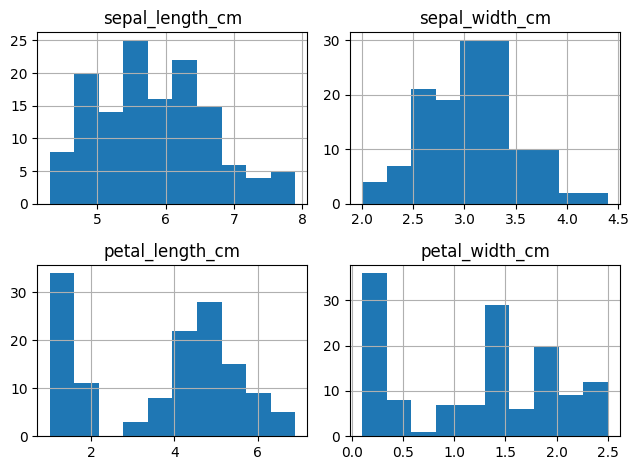

In [98]:
#Análisis univariado
df_train.hist()
plt.tight_layout()
plt.show()
#Sepal_length es casi simetrico parece que se traslapa
#Sepal_width es casi simetrico
#Petal parece que hay dos distribuciones
#Cuales son las variables más discrimitativa, el largo y ancho del petalo por que esta separado

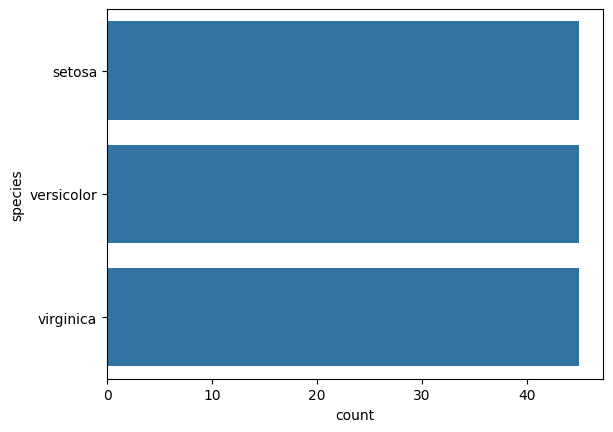

In [99]:
#Conteo por categoria de univariado
sns.countplot(df_train, y='species')
plt.show()

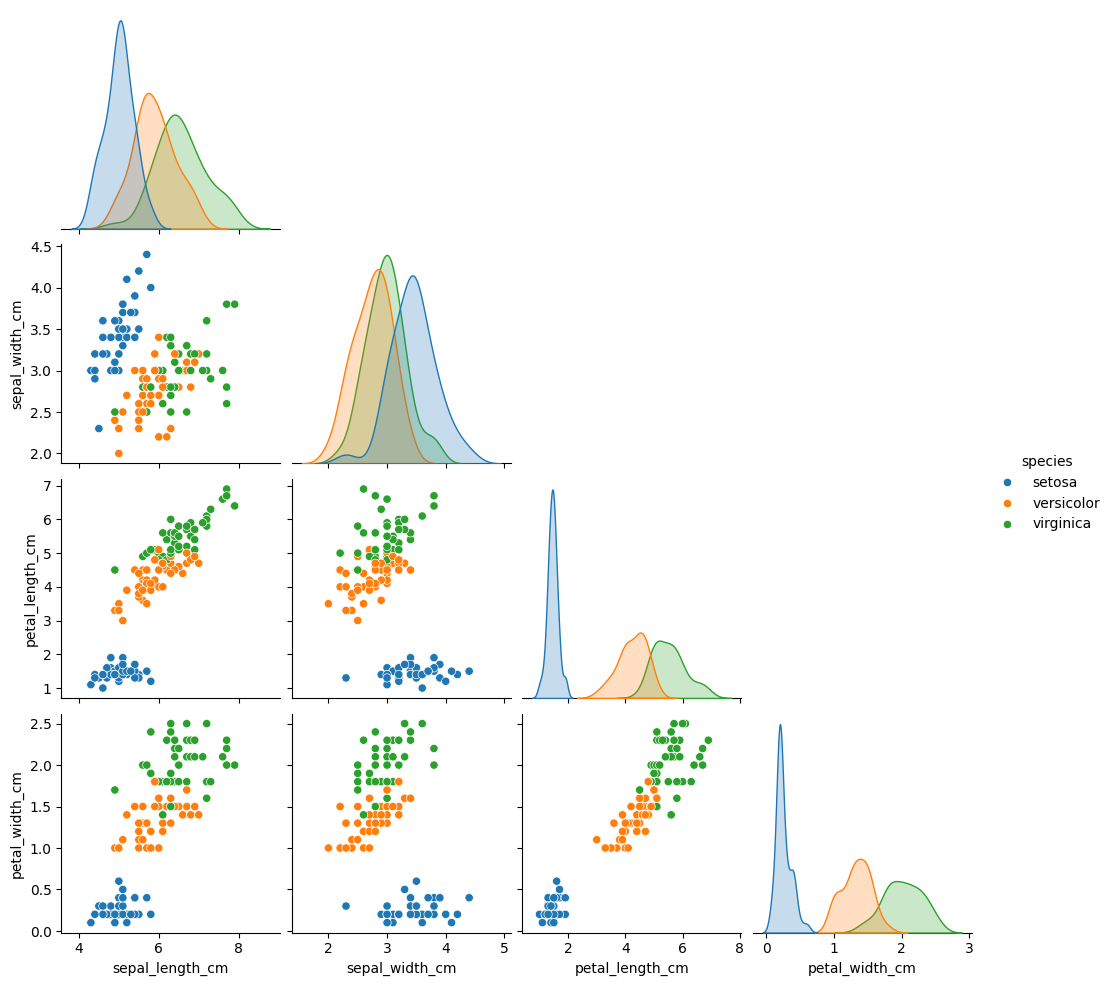

In [100]:
#Análisis bivariado
sns.pairplot(df_train, hue='species', corner=True)
plt.show()
#La setosa esta separado del resto en petal, pero en petal width está más separado
#Cuanto más separada esta la media mejor discirminador de species será la variable y es mayor en petal_with
#La memorización del dataset de aprendizaje se llama Overfiting, si es más profundo ocurre el Overfiting
#La hoja debe de tener mayor pureza posible, las medidas de pureza (Purity) son:
#-Gini Coefficient
#-Entropy
#en sklearn baja hasta que todas las hojas sean puras, la idea es bajar el parametro de profundidad Depth
#La idea es generalizar no memorizar, se controla el overfiting con la profundidad
##
#Cuanto más largo el  sepalo, más ancho es el sepalo, por eso la linea azul hacen una linea, el petal length con el petal width es igual
#La correlación de Pearson es en ausencia de cateogrías
#El petal length con el petal width tambien hay una línea

<Axes: >

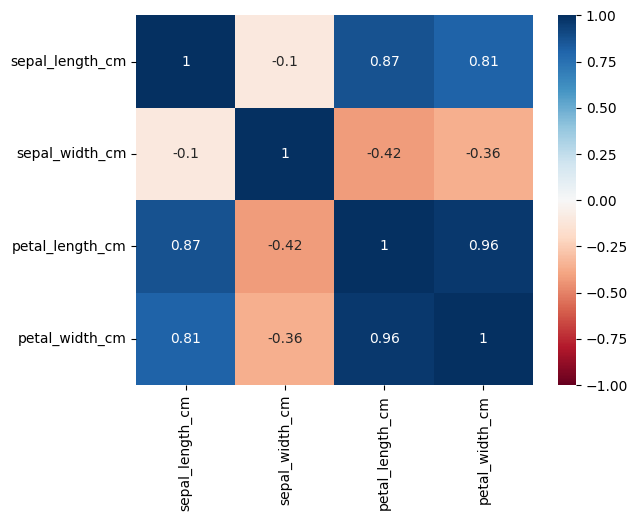

In [101]:
#Gráfica de correlación
sns.heatmap(df_train.select_dtypes('number').corr(), vmin=-1, vmax=1, cmap='RdBu', annot=True)#annot para poder ver el valor
#La mejor correlación es 0.96 y 0.87
#En LR no puede haber correlación, pero en arbol de decision si puede haber


In [6]:
#Step 4: ML
#Empieza la separacion de la matriz de predicción
X_train = df_train.drop(columns='species')
y_train = df_train['species']
#type(X_train) #pandas.core.frame.DataFrame
#type(y_train) #pandas.core.series.Series

X_test = df_train.drop(columns='species')
y_test = df_train['species']

#La columna species tiene texto y para que el ML lo interprete tiene que ser número, regresar a 0,1 y 2
#LabelEncoder convierte la variable categorica a número y lo memoriza

X_test.shape, y_test.shape

((135, 4), (135,))

In [103]:
encoder =LabelEncoder()
y_train_enc = encoder.fit_transform(y_train) #Para la columan  de aprendizaje se econdea con fit_transfor
y_test_enc = encoder.transform(y_test) #Para la columna de prueba se encodea con transform

y_test_enc
#Si no colocamos en el preprocessing el species como categorico todo se desborda no hay sentido en la estadistica descriptiva,
#en las gráficas, pero para el ML tiene que volver a numérico

array([2, 1, 1, 2, 2, 1, 0, 0, 0, 1, 0, 1, 0, 1, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 2, 2, 2, 2, 0, 1, 0, 0, 2,
       0, 2, 1, 1, 2, 2, 2, 0, 2, 2, 0, 0, 0, 1, 1, 1, 2, 1, 1, 0, 1, 0,
       2, 0, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 0, 0, 1, 1, 0, 1, 2, 0, 0, 2,
       0, 2, 0, 1, 2, 0, 2, 0, 0, 2, 1, 0, 1, 1, 0, 2, 0, 0, 1, 2, 0, 1,
       0, 0, 2, 1, 1, 2, 2, 2, 0, 0, 2, 1, 2, 1, 1, 0, 1, 1, 2, 1, 2, 2,
       0, 1, 1])

In [124]:
tree_clf = DecisionTreeClassifier(random_state= 40, max_depth=2) #en 3 para reducir la profundidad
tree_clf.fit(X_train, y_train_enc) #para el aprendizaje no puede ser el y_train por que es categorico,
#debe ser el encodeado q esta en numérico


DecisionTreeClassifier(max_depth=2, random_state=40)

In [125]:
tree_clf

DecisionTreeClassifier(max_depth=2, random_state=40)

In [126]:
tree_clf.get_params()
#El DecisioTreeClassifier genera reglas y de manera recursiva genera puntos de decision, genera particion de mayor pureza

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 2,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 40,
 'splitter': 'best'}

In [127]:
y_hat = tree_clf.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test_enc, y_hat)}')
#Accuracy: 1.0 Por que salio tan alto? Por que no le dijimos el max depth esta overfiteado
#Si el accuracy es alto no es normal, se debe de cuestionar

Accuracy: 0.9555555555555556


In [128]:
tree_clf.get_depth() #5 con 5 esta overfiteado

2

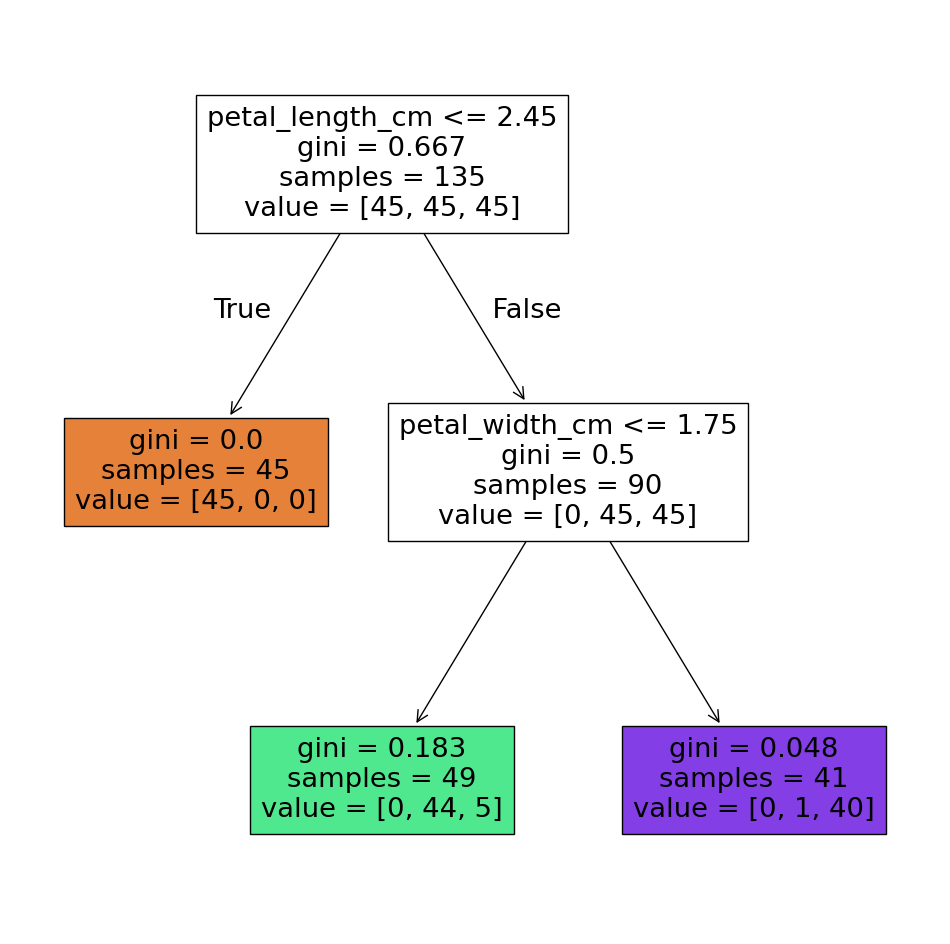

In [133]:
plt.figure(figsize=(12,12))
plot_tree(tree_clf, feature_names=X_train.columns, filled=True, impurity=True) #impurity=False no coloca el varlo del giny
plt.show()

Ahmed, M. et al (2020). Review and Analysis of Risk Factor of Maternal Health in Remote Area Using the Internet of Things (IoT). Conference paper InECCE2019 Lecture Notes in Electrical Engineering ((LNEE,volume 632))

In [24]:
df_raw = pd.read_csv('/Maternal Health Risk Data Set.csv')
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [25]:
df_raw.sample(10, random_state= 2025)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
109,32,140,100,7.9,98.0,78,high risk
185,55,100,65,6.1,98.0,66,low risk
402,35,100,70,7.8,98.0,60,low risk
800,32,120,80,6.8,98.0,70,mid risk
684,32,140,100,6.9,98.0,78,high risk
555,50,130,100,16.0,98.0,75,mid risk
34,21,75,50,6.1,98.0,70,low risk
689,40,160,100,19.0,98.0,77,high risk
172,20,100,90,7.1,98.0,88,low risk
528,15,78,49,7.5,98.0,77,low risk


In [36]:
#Step 2 Preprocessing
df_baking = df_raw.copy()
df_baking.columns = df_baking.columns.str.lower()
df_baking['risklevel'] = df_baking['risklevel'].astype('category')
df_baking['heartrate'] = df_baking['heartrate'].apply(lambda x: 76 if x < 60 else x)
df = df_baking.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          1014 non-null   int64   
 1   systolicbp   1014 non-null   int64   
 2   diastolicbp  1014 non-null   int64   
 3   bs           1014 non-null   float64 
 4   bodytemp     1014 non-null   float64 
 5   heartrate    1014 non-null   int64   
 6   risklevel    1014 non-null   category
dtypes: category(1), float64(2), int64(4)
memory usage: 48.8 KB


In [38]:
#Step 3 EDA
df_train, df_test = train_test_split(df, test_size=0.15, stratify=df['risklevel'], random_state=2025)
#Por ser variable cateogrica dependiente -> stratify=['risklevel']
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.shape, df_test.shape

((861, 7), (153, 7))

In [39]:
#Estadsitica descriptiva
display(df_train.describe(include='number').T)
display(df_train.describe(include='category').T)
#El lowrisk es mas frecuente 345/861 = 0.4 el 40% de los datos es risklevel low, es un dataset desbalanceado

,count,mean,std,min,25%,50%,75%,max
age,861.0,29.897793,13.658161,10.0,19.0,25.0,39.0,66.0
systolicbp,861.0,112.926829,18.419353,70.0,95.0,120.0,120.0,160.0
diastolicbp,861.0,76.292683,13.882909,49.0,65.0,80.0,90.0,100.0
bs,861.0,8.732334,3.282029,6.0,6.9,7.5,8.0,19.0
bodytemp,861.0,98.647387,1.357077,98.0,98.0,98.0,98.0,103.0
heartrate,861.0,74.314750,7.551660,60.0,70.0,76.0,80.0,90.0


,count,unique,top,freq
risklevel,861,3,low risk,345


[]

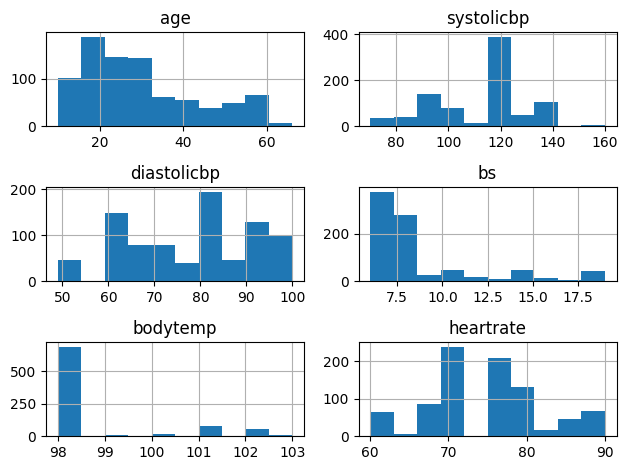

In [40]:
#Analisis univariado
df_train.hist()
plt.tight_layout()
plt.plot()
#Age y bd tienen sesgo positivo
#Bodytemp pordria convertirse en una variable categorica
#heartrate esta pegado a la derecha y a la izquierda hay un dato errado con valor de 7 que no es logico

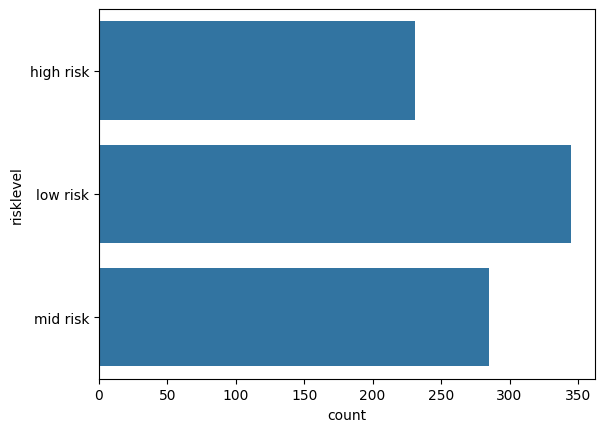

In [41]:
sns.countplot(df_train, y='risklevel')
plt.show()

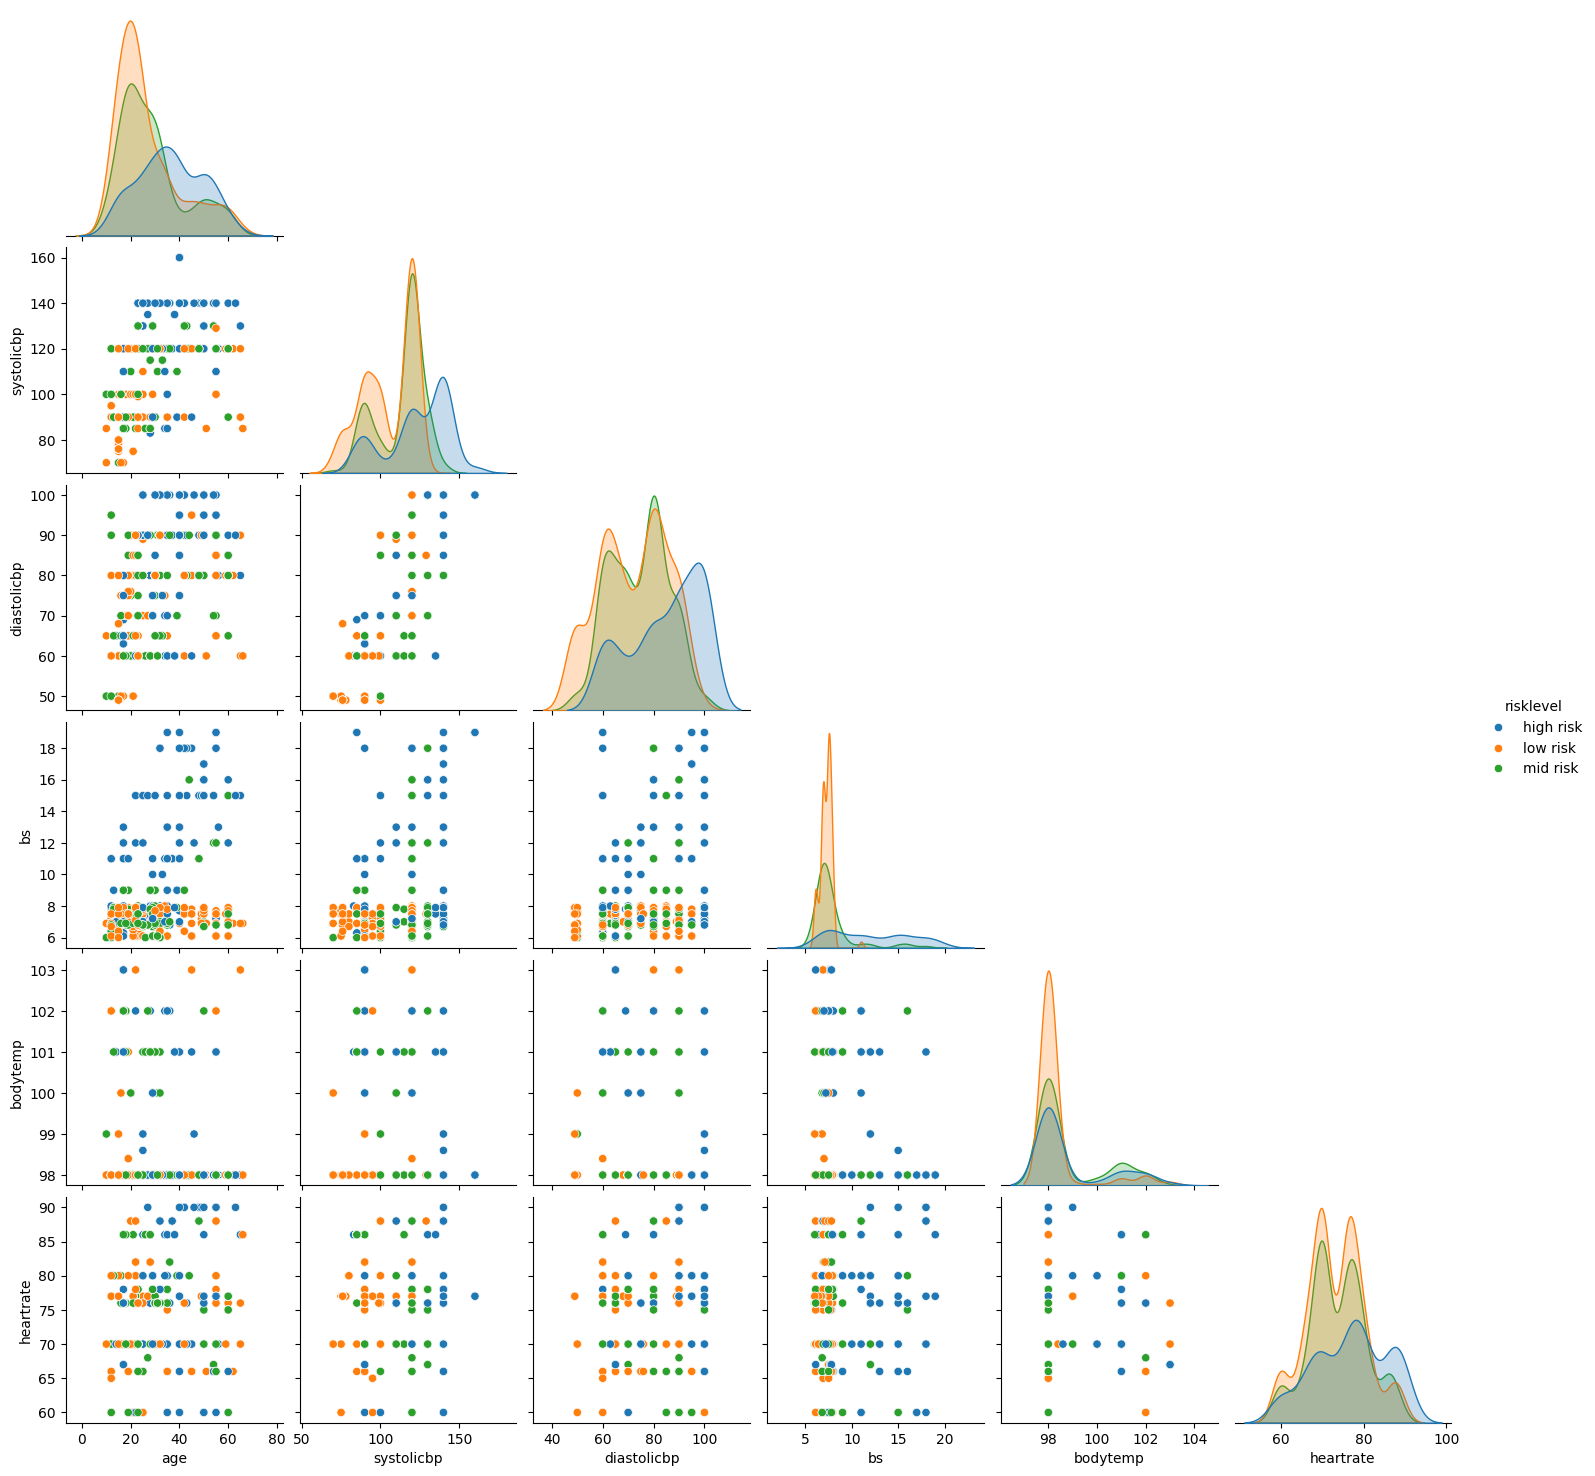

In [44]:
#Analisis bivariado
sns.pairplot(df_train, hue='risklevel', corner =True)
plt.show()

<Axes: >

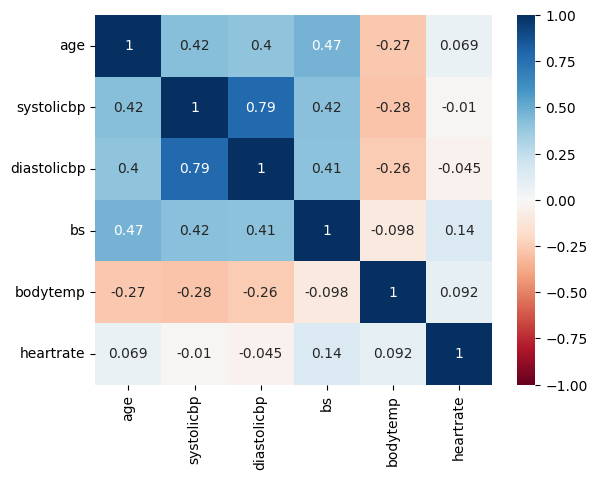

In [46]:
sns.heatmap(df_train.select_dtypes('number').corr(), vmin=-1, vmax=1, cmap='RdBu', annot=True)

In [47]:
#Step 4: ML
#Empieza la separacion de la matriz de predicción
X_train = df_train.drop(columns='risklevel')
y_train = df_train['risklevel']
#type(X_train) #pandas.core.frame.DataFrame
#type(y_train) #pandas.core.series.Series

X_test = df_train.drop(columns='risklevel')
y_test = df_train['risklevel']

X_test.shape, y_test.shape

((861, 6), (861,))

In [48]:
encoder =LabelEncoder()
y_train_enc = encoder.fit_transform(y_train) #Para la columan  de aprendizaje se econdea con fit_transfor
y_test_enc = encoder.transform(y_test) #Para la columna de prueba se encodea con transform

y_test_enc

array([0, 1, 1, 0, 0, 1, 1, 1, 2, 0, 1, 2, 0, 0, 1, 1, 2, 1, 1, 2, 1, 0,
       1, 2, 1, 2, 0, 0, 0, 1, 0, 2, 0, 2, 2, 1, 1, 2, 0, 2, 0, 2, 2, 1,
       2, 2, 2, 1, 2, 1, 0, 1, 1, 2, 2, 0, 1, 2, 2, 1, 0, 1, 2, 2, 2, 1,
       2, 1, 1, 2, 0, 0, 1, 1, 1, 1, 2, 1, 2, 0, 1, 1, 1, 2, 2, 2, 1, 0,
       1, 0, 1, 1, 0, 2, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0,
       1, 2, 1, 1, 0, 0, 2, 0, 2, 0, 2, 1, 2, 1, 2, 2, 0, 1, 1, 2, 1, 1,
       2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 2, 1,
       2, 1, 2, 2, 2, 1, 2, 2, 2, 0, 0, 1, 0, 2, 1, 2, 0, 0, 1, 2, 2, 0,
       0, 1, 1, 0, 2, 0, 0, 2, 0, 0, 1, 1, 1, 1, 2, 0, 1, 2, 1, 1, 2, 2,
       1, 1, 1, 1, 1, 2, 1, 1, 0, 0, 1, 1, 2, 0, 0, 2, 1, 1, 0, 1, 1, 0,
       2, 0, 2, 1, 0, 2, 1, 1, 2, 2, 1, 1, 1, 0, 1, 0, 1, 2, 0, 2, 0, 2,
       2, 2, 1, 2, 0, 2, 2, 1, 1, 0, 2, 0, 0, 0, 1, 1, 0, 0, 2, 2, 2, 1,
       1, 2, 0, 1, 2, 1, 1, 0, 1, 0, 0, 0, 2, 2, 2, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 2, 0, 2, 1, 0, 1,

In [50]:
tree_clf = DecisionTreeClassifier(random_state= 2025, class_weight='balanced')
tree_clf.fit(X_train, y_train_enc)

DecisionTreeClassifier(class_weight='balanced', random_state=2025)

In [52]:
y_hat = tree_clf.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test_enc, y_hat)}')

Accuracy: 0.9221835075493612


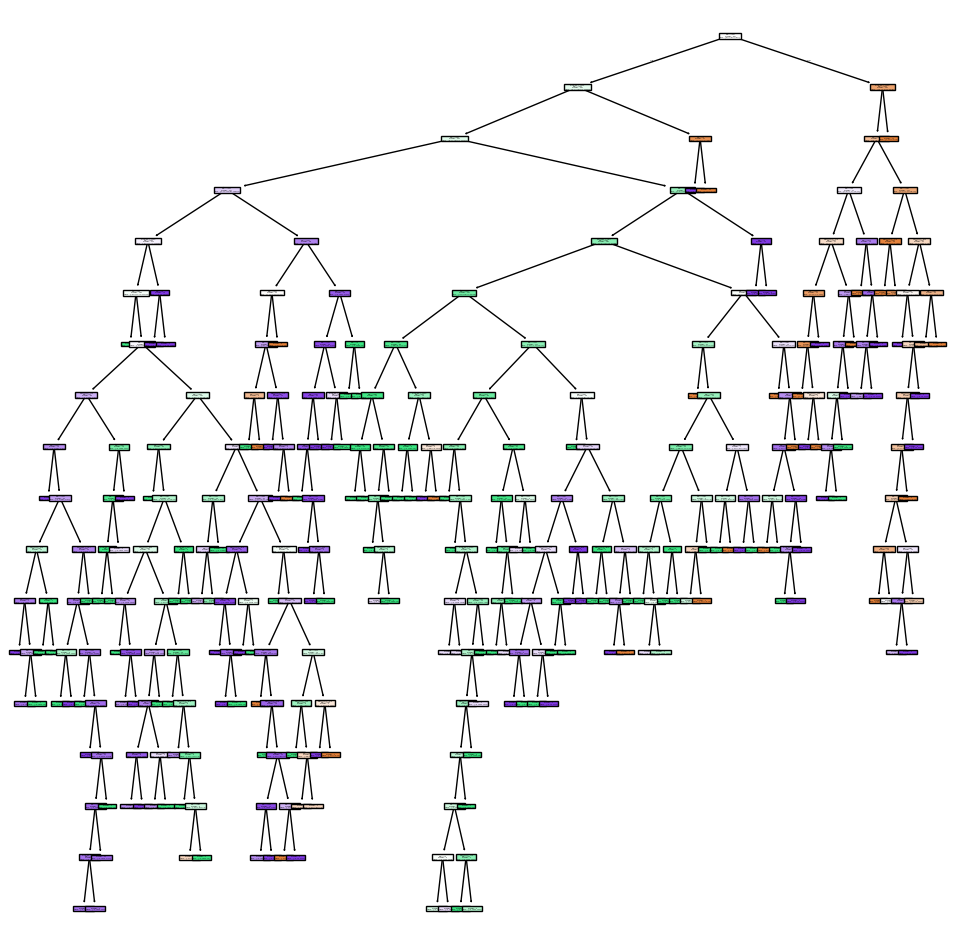

In [53]:
plt.figure(figsize=(12,12))
plot_tree(tree_clf, feature_names=X_train.columns, filled=True, impurity=True) #impurity=False no coloca el varlo del giny
plt.show()

In [57]:
tree_clf_cv = GridSearchCV(
    tree_clf,
    param_grid = {
        'max_depth': [1,2,3,4,5,6,7], #Va ir probando estas profundidades
        'min_samples_leaf': [1,2,4,6] #hojas
        },
    cv = 5,
    scoring = 'accuracy'
)

tree_clf_cv.fit(X_train, y_train_enc)
tree_clf_cv.best_params_
#La mejor profundidad es 7 y con una cantidad de muestra de hojas de 1

{'max_depth': 7, 'min_samples_leaf': 1}